In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import statistics

In [57]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [58]:
data = pd.read_csv('NP15_rt_series.csv')
data['begin_time'] = pd.to_datetime(data['begin_time'])
data_15min = data[data['begin_time'].apply(lambda x : x.minute%15 == 0)].copy()
data_15min

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price
0,2021-01-01 00:00:00,30.76070,NaN,NaN
3,2021-01-01 00:15:00,31.35044,NaN,NaN
6,2021-01-01 00:30:00,32.45147,NaN,NaN
9,2021-01-01 00:45:00,29.98897,NaN,NaN
12,2021-01-01 01:00:00,29.89887,NaN,NaN
...,...,...,...,...
420753,2024-12-31 22:45:00,45.92347,6.20218,39.72129
420756,2024-12-31 23:00:00,46.50217,8.26084,38.24133
420759,2024-12-31 23:15:00,46.25834,7.86632,38.39202
420762,2024-12-31 23:30:00,45.51538,9.08338,36.43200


In [59]:
exog = pd.read_csv('NP15_exog.csv')
exog['begin_time'] = pd.to_datetime(exog['begin_time'])
exog

,begin_time,load,Pacific Gas and Electric Forecast Load (MW),solar_forecast,wind_forecast,NP15 Solar Generation (MW),NP15 Wind Generation (MW),Natural_gas_price
0,2021-03-12 00:00:00,9914.0,10102.72,0.0,327.97,-2.69832,526.78168,2.65
1,2021-03-12 01:00:00,9827.0,9868.57,0.0,259.94,-2.66009,405.97186,2.65
2,2021-03-12 02:00:00,9849.0,9712.50,0.0,191.44,-2.68074,288.43194,2.65
3,2021-03-12 03:00:00,9939.0,9715.76,0.0,148.07,-2.68692,205.85381,2.65
4,2021-03-12 04:00:00,10287.0,9969.51,0.0,134.36,-2.58009,173.78675,2.65
...,...,...,...,...,...,...,...,...
33379,2024-12-31 19:00:00,11307.0,11959.79,0.0,48.25,-3.03842,58.35641,3.40
33380,2024-12-31 20:00:00,10967.0,11723.02,0.0,55.64,-7.19792,65.56839,3.40
33381,2024-12-31 21:00:00,10614.0,11408.80,0.0,65.90,-6.79170,62.77812,3.40
33382,2024-12-31 22:00:00,10226.0,10831.46,0.0,77.46,-6.26466,54.79276,3.40


In [60]:
def interpolate_exog(df):
    df['begin_time'] = pd.to_datetime(df['begin_time'])
    df.set_index('begin_time', inplace=True)
    df = df.groupby(df.index).mean()
    dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='15min')
    df = df.reindex(dates)
    df.reset_index(inplace=True)
    df.rename(columns={'index':'begin_time'}, inplace=True)
    df.ffill(inplace=True)
    return df

In [61]:
exog = interpolate_exog(exog)
data_comb = pd.merge(data_15min, exog, how='inner', on='begin_time')
data_comb

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price,load,Pacific Gas and Electric Forecast Load (MW),solar_forecast,wind_forecast,NP15 Solar Generation (MW),NP15 Wind Generation (MW),Natural_gas_price
0,2021-03-12 00:00:00,34.56084,-21.12893,55.68977,9914.0,10102.72,0.0,327.97,-2.69832,526.78168,2.65
1,2021-03-12 00:15:00,35.35549,-25.15432,60.50981,9914.0,10102.72,0.0,327.97,-2.69832,526.78168,2.65
2,2021-03-12 00:30:00,34.51972,-22.99046,57.51018,9914.0,10102.72,0.0,327.97,-2.69832,526.78168,2.65
3,2021-03-12 00:45:00,32.77203,-14.96161,47.73364,9914.0,10102.72,0.0,327.97,-2.69832,526.78168,2.65
4,2021-03-12 01:00:00,33.10504,-18.19313,51.29817,9827.0,9868.57,0.0,259.94,-2.66009,405.97186,2.65
...,...,...,...,...,...,...,...,...,...,...,...
133528,2024-12-31 22:00:00,46.56593,2.44625,44.11968,10226.0,10831.46,0.0,77.46,-6.26466,54.79276,3.40
133529,2024-12-31 22:15:00,46.33350,2.58961,43.74389,10226.0,10831.46,0.0,77.46,-6.26466,54.79276,3.40
133530,2024-12-31 22:30:00,47.24685,4.88912,42.35773,10226.0,10831.46,0.0,77.46,-6.26466,54.79276,3.40
133531,2024-12-31 22:45:00,45.92347,6.20218,39.72129,10226.0,10831.46,0.0,77.46,-6.26466,54.79276,3.40


In [62]:
data_comb['load_diffs']=data_comb['load']-data_comb['Pacific Gas and Electric Forecast Load (MW)']
data_comb['load_diffs_prevtime']=data_comb['load_diffs'].shift(1)
data_comb['solar_diffs']=data_comb['NP15 Solar Generation (MW)']-data_comb['solar_forecast']
data_comb['solar_diffs_prevtime']=data_comb['solar_diffs'].shift(1)
data_comb['wind_diffs']=data_comb['NP15 Wind Generation (MW)']-data_comb['wind_forecast']
data_comb['wind_diffs_prevtime']=data_comb['wind_diffs'].shift(1)
data_comb['load_prevtime'] = data_comb['load'].shift(1)
data_comb['solar_prevtime'] = data_comb['NP15 Solar Generation (MW)'].shift(1)
data_comb['wind_prevtime'] = data_comb['NP15 Wind Generation (MW)'].shift(1)

In [63]:
data_train=data_comb.iloc[:106826]
data_train

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price,load,Pacific Gas and Electric Forecast Load (MW),solar_forecast,wind_forecast,NP15 Solar Generation (MW),NP15 Wind Generation (MW),Natural_gas_price,load_diffs,load_diffs_prevtime,solar_diffs,solar_diffs_prevtime,wind_diffs,wind_diffs_prevtime,load_prevtime,solar_prevtime,wind_prevtime
0,2021-03-12 00:00:00,34.56084,-21.12893,55.68977,9914.0,10102.72,0.00,327.97,-2.69832,526.78168,2.65,-188.72,NaN,-2.69832,NaN,198.81168,NaN,NaN,NaN,NaN
1,2021-03-12 00:15:00,35.35549,-25.15432,60.50981,9914.0,10102.72,0.00,327.97,-2.69832,526.78168,2.65,-188.72,-188.72,-2.69832,-2.69832,198.81168,198.81168,9914.0,-2.69832,526.78168
2,2021-03-12 00:30:00,34.51972,-22.99046,57.51018,9914.0,10102.72,0.00,327.97,-2.69832,526.78168,2.65,-188.72,-188.72,-2.69832,-2.69832,198.81168,198.81168,9914.0,-2.69832,526.78168
3,2021-03-12 00:45:00,32.77203,-14.96161,47.73364,9914.0,10102.72,0.00,327.97,-2.69832,526.78168,2.65,-188.72,-188.72,-2.69832,-2.69832,198.81168,198.81168,9914.0,-2.69832,526.78168
4,2021-03-12 01:00:00,33.10504,-18.19313,51.29817,9827.0,9868.57,0.00,259.94,-2.66009,405.97186,2.65,-41.57,-188.72,-2.66009,-2.69832,146.03186,198.81168,9914.0,-2.69832,526.78168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106821,2024-03-28 17:15:00,12.28916,-16.96537,29.25453,9959.0,9525.27,688.36,579.60,454.61691,498.32691,1.54,433.73,433.73,-233.74309,-233.74309,-81.27309,-81.27309,9959.0,454.61691,498.32691
106822,2024-03-28 17:30:00,32.78911,5.34849,27.44062,9959.0,9525.27,688.36,579.60,454.61691,498.32691,1.54,433.73,433.73,-233.74309,-233.74309,-81.27309,-81.27309,9959.0,454.61691,498.32691
106823,2024-03-28 17:45:00,51.68044,4.46656,47.21388,9959.0,9525.27,688.36,579.60,454.61691,498.32691,1.54,433.73,433.73,-233.74309,-233.74309,-81.27309,-81.27309,9959.0,454.61691,498.32691
106824,2024-03-28 18:00:00,25.27534,4.62560,20.64974,10702.0,10478.10,224.75,577.32,49.33113,534.65286,1.54,223.90,433.73,-175.41887,-233.74309,-42.66714,-81.27309,9959.0,454.61691,498.32691


In [89]:
def crossValidateFinal(year, n_splits, test_size, seas_order, non_seas_order):
    ts_split = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    mse_list = []
    mse_base_list = []

    print(f"Seasonal order - {seas_order}, Non-seasonal order - {non_seas_order}")

    for tod in range(0, 2):
      for j in range(3,13, 3):
          time1 = datetime.datetime(year, j, 1, 0, 0, 0)
          time2 = datetime.datetime(year, j, 28, (12 + (6*tod)), 0, 0)
          df = data_train[filter_times(data_train, time1, time2)].copy().reset_index(drop=True)
          for i, (train_index, test_index) in enumerate(ts_split.split(df)):
              model = SARIMAX(endog=df['NP-15 LMP'].loc[train_index], exog=df[['Natural_gas_price', 'load_diffs_prevtime', 'solar_diffs_prevtime', 'wind_diffs_prevtime', 'solar_prevtime', 'wind_prevtime', 'load_prevtime']].loc[train_index], trend='c', order=non_seas_order, seasonal_order=seas_order)
              model_fit = model.fit()
              forecast = model_fit.forecast(test_size, exog=df[['Natural_gas_price', 'load_diffs_prevtime', 'solar_diffs_prevtime', 'wind_diffs_prevtime', 'solar_prevtime', 'wind_prevtime', 'load_prevtime']].loc[test_index]).to_frame(name='predicted')
              eval_df = pd.merge(df[['NP-15 LMP', 'NP-15 LMP Prev_day_price']].loc[test_index].copy(), forecast, left_index=True, right_index=True, how='inner')
              #eval_df = eval_df[eval_df.apply(lambda x: (x['NP-15 LMP'].isna()==False) and (x['NP-15 LMP Prev_day_price'].isna()==False))]
              eval_df = eval_df[(eval_df['NP-15 LMP'].isna()==False)]
              eval_df = eval_df[(eval_df['NP-15 LMP Prev_day_price'].isna()==False)]
              if eval_df.empty == False:
                  mse = mean_squared_error(eval_df['NP-15 LMP'], eval_df['predicted'])
                  mse_base = mean_squared_error(eval_df['NP-15 LMP'], eval_df['NP-15 LMP Prev_day_price'])
                  mse_list.append(mse)
                  mse_base_list.append(mse_base)
                  #print(f"mse for validation from time {df['begin_time'].loc[test_index[0]]} to {df['begin_time'].loc[test_index[-1]]} , fold {i} = {mse}. Baseline = {mse_base}")
              #print(model_fit.summary())
              #mse = mean_squared_error(df['NP-15 LMP'].loc[test_index], model_fit.forecast(test_size))
              #mse_list.append(mse)
              #data_predicted = df.join(pd.concat([df['NP-15 LMP'].loc[train_index].tail(test_size), model_fit.forecast(test_size, exog=df[['Natural_gas_price', 'load_diffs_prevtime', 'solar_diffs_prevtime', 'wind_diffs_prevtime', 'solar_prevtime', 'wind_prevtime', 'load_prevtime']].loc[test_index])]).to_frame(name='predicted'), how='inner')
              #plt.figure(figsize=(18, 4))
              #plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP Prev_day_price'] , label='Previous day price')
              #plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP'] , label='Actual price')
              #plt.plot(data_predicted['begin_time'], data_predicted['predicted'] , label='Predicted')
              #plt.xticks(rotation=90)
              #plt.legend()
              #plt.show()
      print(f"tod {tod} done.")

    print(f"Validation error for {year} = {statistics.fmean(mse_list)}, baseline = {statistics.fmean(mse_base_list)}")

In [84]:
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (0,0,0))
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (0,1,0))
#crossValidateFinal(2023, 3, 8, (0,1,0, 96), (1,0,0)) Fails to converge

Seasonal order - (0, 1, 0, 96), Non-seasonal order - (0, 0, 0)
tod 0 done.
tod 1 done.
Validation error for 2023 = 287.23965325761566, baseline = 1950.9388681499104
Seasonal order - (0, 1, 0, 96), Non-seasonal order - (0, 1, 0)
tod 0 done.
tod 1 done.
Validation error for 2023 = 466.9753617546159, baseline = 1950.9388681499104
Seasonal order - (0, 1, 0, 96), Non-seasonal order - (1, 0, 0)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


tod 0 done.


KeyboardInterrupt: 

In [90]:
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (1,1,0))

Seasonal order - (0, 1, 0, 96), Non-seasonal order - (1, 1, 0)
tod 0 done.
tod 1 done.
Validation error for 2023 = 434.8647855877363, baseline = 2007.4000075839724


In [80]:
crossValidateFinal(2022, 3, 8, (0,1,0, 24), (0,1,0))

Seasonal order - (0, 1, 0, 24), Non-seasonal order - (0, 1, 0)
Month 3 done.
Month 6 done.
Month 9 done.
Month 12 done.
Month 3 done.
Month 6 done.
Month 9 done.
Month 12 done.
Validation error for 2022 = 21938.92121059309, baseline = 13645.997585851464


In [22]:
crossValidateFinal(2022, 3, 8, (1,1,0, 24), (0,1,0), 2)
crossValidateFinal(2022, 3, 8, (1,1,0, 24), (0,1,0), 1)
crossValidateFinal(2022, 3, 8, (1,1,0, 24), (0,1,0), 0)

Seasonal order - (1, 1, 0, 24), Non-seasonal order - (0, 1, 0)
mse for validation from time 2022-03-28 17:15:00 to 2022-03-28 19:00:00 , fold 0 = 494.49824117036553. Baseline = 826.7641299519858
mse for validation from time 2022-03-28 19:15:00 to 2022-03-28 21:00:00 , fold 1 = 79627.58645865806. Baseline = 291.98005557602494
mse for validation from time 2022-03-28 21:15:00 to 2022-03-28 23:00:00 , fold 2 = 399.51121038996024. Baseline = 11.201923721525011
Month 3 done.
mse for validation from time 2022-06-28 17:15:00 to 2022-06-28 19:00:00 , fold 0 = 837.7686416459608. Baseline = 661.3853215050374
mse for validation from time 2022-06-28 19:15:00 to 2022-06-28 21:00:00 , fold 1 = 260.28371689879043. Baseline = 413.60401893020014
mse for validation from time 2022-06-28 21:15:00 to 2022-06-28 23:00:00 , fold 2 = 890.3789124215341. Baseline = 1353.4839107187872
Month 6 done.
mse for validation from time 2022-09-28 17:15:00 to 2022-09-28 19:00:00 , fold 0 = 648.0342816517742. Baseline = 145

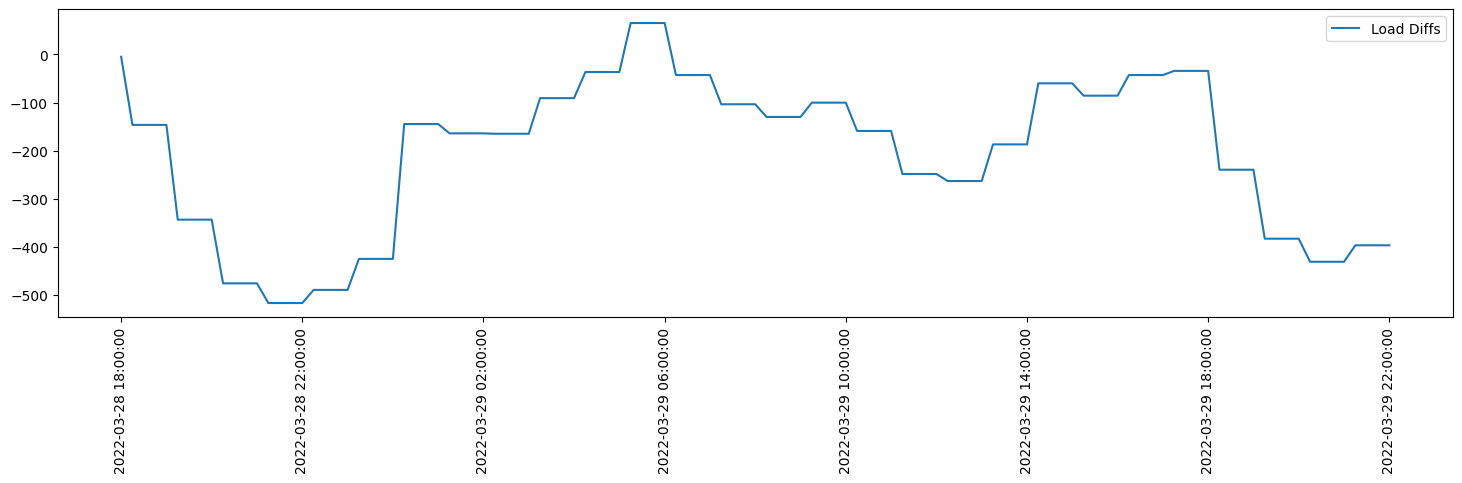

In [26]:
time1 = datetime.datetime(2022, 3, 28, 18, 0, 0)
time2 = datetime.datetime(2022, 3, 29, 22, 0, 0)

filtered_data = data_comb[filter_times(data_comb, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['load_diffs_prevtime'] , label='Load Diffs')


plt.xticks(ticks=pd.date_range(start=time1, end=time2, freq='4h'), labels=pd.date_range(start=time1, end=time2, freq='4h'), rotation=90)
plt.legend()
plt.show()